In [3]:
using HDF5
using PyPlot
using ProgressBars
using JLD2
using Images, ImageFiltering
using Statistics

In [4]:
function load_imgs(filenames, pathdir)
    imgs_atoms, imgs_bkg, imgs_dark = [], [], []

    for filename in filenames
        filename = pathdir*filename
        h5open(filename, "r") do file
            img_atoms = convert(Matrix{Int}, read(file["images/Vertical_Axis_Camera/in_situ_absorption/atoms"]))
            img_bkg = convert(Matrix{Int}, read(file["images/Vertical_Axis_Camera/in_situ_absorption/background"]))
            img_dark = convert(Matrix{Int}, read(file["images/Vertical_Axis_Camera/in_situ_absorption/dark"]))
            push!(imgs_atoms, img_atoms), push!(imgs_bkg, img_bkg), push!(imgs_dark, img_dark)
        end
    end
    return imgs_atoms, imgs_bkg, imgs_dark
end

function crop_imgs(imgs, x_crop, y_crop, mask)
    imgs_crop = []
    for i = 1:length(imgs)
        img_crop = imgs[i][y_crop, x_crop]
        push!(imgs_crop, img_crop .* mask)
    end
    return imgs_crop
end

function compute_OD(imgs_atoms, imgs_bkg, imgs_dark)
    ODs = []
    for i in 1:length(imgs_atoms)
        OD = (imgs_atoms[i] .- imgs_dark[i]) ./ (imgs_bkg[i] .- imgs_dark[i])
        OD[OD .< 0] .= NaN # Values where dark is brighter than laser/atoms are not taken into account
        OD .= -log10.(OD)
        OD[isnan.(OD)] .= 0 # Map Nan values to 0
        push!(ODs, OD)
    end
    return ODs
end

function mask_ellipse(xc, yc, a, b, θ, x_crop, y_crop)
    mask = zeros(Integer, (length(y_crop), length(x_crop)))
    X = range(0, length(y_crop)-1) .- yc
    Y = range(0, length(x_crop)-1) .- xc
    for (i, x) in enumerate(X)
        for (j, y) in enumerate(Y)
            # Rotate back
            x_hor = x*sin(θ) + y*cos(θ)
            y_hor = x*cos(θ) - y*sin(θ)
            if (x_hor/a)^2 + (y_hor/b)^2 ≤ 1
                mask[i, j] = 1
            end
        end
    end
    return mask
end

mask_ellipse (generic function with 1 method)

In [5]:
pathdir_date = "data/04_07_25/"
dir_names_datasets = readdir(pathdir_date)
dir_names_datasets = dir_names_datasets[dir_names_datasets .!= ".DS_Store"]
I_inc = [0.04, 3, 6].*1e-3 # In W
I_sat = [0.5, 32, 65] # Estimated saturation parameter
τ_exp = [8, 5, 2].*1e-3
x_crop = [1290:1560;]
y_crop = [1840:2210;]
xc, yc, a, b, θ = 140, 200, 70, 40, 1.1;

# Import and crop the images

In [ ]:
imgs_atoms_crop_datasets, imgs_bkg_crop_datasets, imgs_dark_crop_datasets = [], [], []
mask = mask_ellipse(xc, yc, a, b, θ, x_crop, y_crop)

for dir_name_datasets in ProgressBar(dir_names_datasets)
    files_path = readdir(pathdir_date*dir_name_datasets)
    imgs_atoms, imgs_bkg, imgs_dark = load_imgs(files_path, pathdir_date*dir_name_datasets*"/")
    imgs_atoms_crop, imgs_bkg_crop, imgs_dark_crop = crop_imgs(imgs_atoms, x_crop, y_crop, mask), crop_imgs(imgs_bkg, x_crop, y_crop, mask), crop_imgs(imgs_dark, x_crop, y_crop, mask)
    push!(imgs_atoms_crop_datasets, imgs_atoms_crop), push!(imgs_bkg_crop_datasets, imgs_bkg_crop), push!(imgs_dark_crop_datasets, imgs_dark_crop)
end

In [ ]:
@save "Imgs_crop_mask.jld2" imgs_atoms_crop_datasets imgs_bkg_crop_datasets imgs_dark_crop_datasets

In [ ]:
# @load "Imgs_crop.jld2" imgs_atoms_crop_datasets imgs_bkg_crop_datasets imgs_dark_crop_datasets

# Compute the ODs

In [ ]:
ODs_datasets = []
for i in ProgressBar(1:length(imgs_atoms_crop_datasets))
    push!(ODs_datasets, compute_OD(imgs_atoms_crop_datasets[i], imgs_bkg_crop_datasets[i], imgs_dark_crop_datasets[i]))
end

In [ ]:
@save "ODs_crop_mask.jld2" ODs_datasets

In [6]:
@load "ODs_crop_mask.jld2" ODs_datasets

1-element Vector{Symbol}:
 :ODs_datasets

# Save the ODs images

In [ ]:
if !isdir("imgs")
    mkdir("imgs")
end
if !isdir("imgs/ODs_mask")
    mkdir("imgs/ODs_mask")
end
if !isdir("imgs/ODs_mask/"*split(pathdir_date, "/")[2])
    mkdir("imgs/ODs_mask/"*split(pathdir_date, "/")[2])
end
if !isdir("imgs/neg_ODs_mask")
    mkdir("imgs/neg_ODs_mask")
end
if !isdir("imgs/neg_ODs_mask/"*split(pathdir_date, "/")[2])
    mkdir("imgs/neg_ODs_mask/"*split(pathdir_date, "/")[2])
end

### ODs

In [ ]:
close("all")
fig, axs = subplots()

for (i, ODs) in ProgressBar(enumerate(ODs_datasets))
    if !isdir("imgs/ODs_mask/"*split(pathdir_date, "/")[2]*"/"*dir_names_datasets[i])
        mkdir("imgs/ODs_mask/"*split(pathdir_date, "/")[2]*"/"*dir_names_datasets[i])
    end
    for (j, OD) in enumerate(ODs)
        img = axs.imshow(OD, cmap="plasma") #, aspect="auto"
        cb = colorbar(img)
        savefig("imgs/ODs_mask/"*split(pathdir_date, "/")[2]*"/"*dir_names_datasets[i]*"/$(j-1).png")
        cb.remove()
        axs.clear()
    end
end
close("all")

### Find nbr of droplets

In [46]:
function smooth_imgs(img, size_kernel)
    flat_kernel = ones(size_kernel, size_kernel)/size_kernel^2
    img_smooth = imfilter(img, flat_kernel)
    return img_smooth
end

function find_droplets(img, droplet_radius, threshold_droplets)
    blob_centers = []

    # log_kernel = Kernel.LoG(droplet_radius)
    log_kernel = Kernel.gaussian(droplet_radius)
    response = imfilter(img, log_kernel)
    response = response .* droplet_radius^2
    # response = abs.(response) .* droplet_radius^2
    blobs = response .> threshold_droplets#*std(img)

    label_blobs = label_components(blobs)
    for label in 1:maximum(label_blobs)
        inds = findall(label_blobs .== label)
        push!(blob_centers, [mean([i[2]-1 for i in inds]), mean([i[1]-1 for i in inds])])
    end

    return blob_centers, label_blobs
end

find_droplets (generic function with 1 method)

## Find parameters droplet

### For one dataset

In [ ]:
threshold_droplets_set = [3, 3, 2.8]

In [16]:
idx_dataset = 1
size_kernel_smooth = 5
droplet_radius = 2.5
threshold_droplets = 2.9

if !isdir("imgs/find_droplets_params")
    mkdir("imgs/find_droplets_params")
end
if !isdir("imgs/find_droplets_params/$(dir_names_datasets[idx_dataset])")
    mkdir("imgs/find_droplets_params/$(dir_names_datasets[idx_dataset])")
end

close("all")
fig, axs = subplots(1, 3, figsize=(10, 5))

for (i, OD) in enumerate(ODs_datasets[idx_dataset])
    smooth_OD = smooth_imgs(OD, size_kernel_smooth)
    centers, label_blobs = find_droplets(smooth_OD, droplet_radius, threshold_droplets)

    axs[1].imshow(smooth_OD)
    
    axs[2].imshow(label_blobs)
    axs[2].scatter([c[1] for c in centers], [c[2] for c in centers], s=10, marker="x", color="r")

    axs[3].imshow(OD)
    axs[3].scatter([c[1] for c in centers], [c[2] for c in centers], s=10, marker="x", color="r")

    savefig("imgs/find_droplets_params/$(dir_names_datasets[idx_dataset])/$(i-1).png")
    
    # println(threshold_droplets*std(OD))
    # println(threshold_droplets*(maximum(OD)-minimum(OD)))

    for ax in axs
        ax.clear()
    end
end

close("all")

### For one dataset, with severall droplet size

In [51]:
close("all")
log_kernel = Kernel.gaussian(4)*maximum(OD)
imshow(log_kernel)
pygui(true); show()

In [49]:
close("all")
OD = ODs_datasets[1][1]
imshow(normalize(smooth_imgs(OD, size_kernel_smooth)))
pygui(true); show()

In [81]:
function normalize(img)
    img_norm = (img .- minimum(img)) ./ (maximum(img)-minimum(img))
    return img_norm
end

function find_droplets_radius_range(img, droplet_radius_range, threshold_droplets_range)
    blob_centers = []
    response = zeros(size(img))

    for droplet_radius in droplet_radius_range
        log_kernel = Kernel.gaussian(droplet_radius)
        response .+= imfilter(img, log_kernel) #*maximum(log_kernel)
        response = response .* droplet_radius^2
    end
    
    blobs = response .> threshold_droplets_range * std(img)^(1/2)

    label_blobs = label_components(blobs)
    for label in 1:maximum(label_blobs)
        inds = findall(label_blobs .== label)
        push!(blob_centers, [mean([i[2]-1 for i in inds]), mean([i[1]-1 for i in inds])])
    end

    return blob_centers, label_blobs
end

find_droplets_radius_range (generic function with 1 method)

In [78]:
idx_dataset = 2
size_kernel_smooth = 5
droplet_radius_range = [2.3:0.1:2.8;]
threshold_droplets_range = 1500 #[2.2:0.1:3;]640000

if !isdir("imgs/find_droplets_params")
    mkdir("imgs/find_droplets_params")
end
if !isdir("imgs/find_droplets_params/$(dir_names_datasets[idx_dataset])")
    mkdir("imgs/find_droplets_params/$(dir_names_datasets[idx_dataset])")
end

close("all")
fig, axs = subplots(1, 3, figsize=(10, 5))

for (i, OD) in enumerate(ODs_datasets[idx_dataset])
    smooth_norm_OD = normalize(smooth_imgs(OD, size_kernel_smooth)) # Normalize to gaussian kernel
    centers, label_blobs = find_droplets_radius_range(smooth_norm_OD, droplet_radius_range, threshold_droplets_range)

    axs[1].imshow(smooth_norm_OD)
    
    axs[2].imshow(label_blobs)
    axs[2].scatter([c[1] for c in centers], [c[2] for c in centers], s=10, marker="x", color="r")

    axs[3].imshow(OD)
    axs[3].scatter([c[1] for c in centers], [c[2] for c in centers], s=10, marker="x", color="r")

    savefig("imgs/find_droplets_params/$(dir_names_datasets[idx_dataset])/$(i-1).png")
    
    # println(threshold_droplets*std(OD))
    # println(threshold_droplets*(maximum(OD)-minimum(OD)))

    for ax in axs
        ax.clear()
    end
end

close("all")

### For every datasets

In [ ]:
size_kernel_smooth = 5
droplet_radius = 2.5
threshold_droplets = 30
nbr_droplets = zeros((length(ODs_datasets), length(ODs_datasets[1])))

if !isdir("imgs/find_droplets_params")
    mkdir("imgs/find_droplets_params")
end

close("all")
fig, axs = subplots(1, 3, figsize=(10, 5))

for idx_dataset in ProgressBar(1:length(ODs_datasets))
    if !isdir("imgs/find_droplets_params/$(dir_names_datasets[idx_dataset])")
        mkdir("imgs/find_droplets_params/$(dir_names_datasets[idx_dataset])")
    end

    for (i, OD) in enumerate(ODs_datasets[idx_dataset])
        smooth_OD = smooth_imgs(OD, size_kernel_smooth)
        centers, label_blobs = find_droplets(smooth_OD, droplet_radius, threshold_droplets)

        axs[1].imshow(smooth_OD)
        
        axs[2].imshow(label_blobs)
        axs[2].scatter([c[1] for c in centers], [c[2] for c in centers], s=10, marker="x", color="r")

        axs[3].imshow(OD)
        axs[3].scatter([c[1] for c in centers], [c[2] for c in centers], s=10, marker="x", color="r")

        savefig("imgs/find_droplets_params/$(dir_names_datasets[idx_dataset])/$(i-1).png")


        nbr_droplets[idx_dataset, i] = length(centers)

        for ax in axs
            ax.clear()
        end
    end
end

close("all")

### With droplet radius range

In [84]:
size_kernel_smooth = 5
droplet_radius_range = [3:0.2:4;]
threshold_droplets_range = 6000000
# threshold_droplets_range = 10000000#1550
# threshold_droplets_range = 6000000#1550
# droplet_radius_range = [2.3:0.1:2.8;]
nbr_droplets = zeros((length(ODs_datasets), length(ODs_datasets[1])))

if !isdir("imgs/find_droplets_params")
    mkdir("imgs/find_droplets_params")
end

close("all")
fig, axs = subplots(1, 3, figsize=(10, 5))

for idx_dataset in ProgressBar(1:length(ODs_datasets))
    if !isdir("imgs/find_droplets_params/$(dir_names_datasets[idx_dataset])")
        mkdir("imgs/find_droplets_params/$(dir_names_datasets[idx_dataset])")
    end

    for (i, OD) in enumerate(ODs_datasets[idx_dataset])
        smooth_norm_OD = normalize(smooth_imgs(OD, size_kernel_smooth)) # Normalize to gaussian kernel
        centers, label_blobs = find_droplets_radius_range(smooth_norm_OD, droplet_radius_range, threshold_droplets_range)

        axs[1].imshow(smooth_norm_OD)
        
        axs[2].imshow(label_blobs)
        axs[2].scatter([c[1] for c in centers], [c[2] for c in centers], s=10, marker="x", color="r")

        axs[3].imshow(OD)
        axs[3].scatter([c[1] for c in centers], [c[2] for c in centers], s=10, marker="x", color="r", alpha=0.5)

        savefig("imgs/find_droplets_params/$(dir_names_datasets[idx_dataset])/$(i-1).png")


        nbr_droplets[idx_dataset, i] = length(centers)

        for ax in axs
            ax.clear()
        end
    end
end

close("all")

0.0%┣                                                ┫ 0/3 [00:00<00:00, -0s/it]
33.3%┣██████████████▍                            ┫ 1/3 [00:29<Inf:Inf, InfGs/it]
66.7%┣███████████████████████████████▍               ┫ 2/3 [01:00<01:00, 60s/it]
100.0%┣██████████████████████████████████████████████┫ 3/3 [01:30<00:00, 45s/it]
100.0%┣██████████████████████████████████████████████┫ 3/3 [01:30<00:00, 45s/it]


### Negative ODs

In [ ]:
close("all")
fig, axs = subplots()

for (i, ODs) in ProgressBar(enumerate(ODs_datasets))
    if !isdir("imgs/neg_ODs_mask/"*split(pathdir_date, "/")[2]*"/"*dir_names_datasets[i])
        mkdir("imgs/neg_ODs_mask/"*split(pathdir_date, "/")[2]*"/"*dir_names_datasets[i])
    end
    for (j, OD) in enumerate(ODs)
        img = axs.imshow(OD, cmap="bone", vmin=-0.2, vmax=0) #, aspect="auto"
        cb = colorbar(img)
        savefig("imgs/neg_ODs_mask/"*split(pathdir_date, "/")[2]*"/"*dir_names_datasets[i]*"/$(j-1).png")
        cb.remove()
        axs.clear()
    end
end
close("all")

# Compute the negative OD for each dataset

In [85]:
sum_neg_OD_norm_drop = zeros((length(ODs_datasets), length(ODs_datasets[1])))

for (i, ODs) in ProgressBar(enumerate(ODs_datasets))
    for j in 1:length(ODs)
        sum_neg_OD_norm_drop[i, j] = sum(ODs[j][ODs[j] .< 0])/nbr_droplets[i, j]
    end
end

0.0%┣                                                ┫ 0/3 [00:00<00:00, -0s/it]
33.3%┣██████████████▍                            ┫ 1/3 [00:00<Inf:Inf, InfGs/it]
100.0%┣███████████████████████████████████████████████┫ 3/3 [00:00<00:00, 7it/s]
100.0%┣███████████████████████████████████████████████┫ 3/3 [00:00<00:00, 7it/s]


### Plot as a function of the lasers intensity

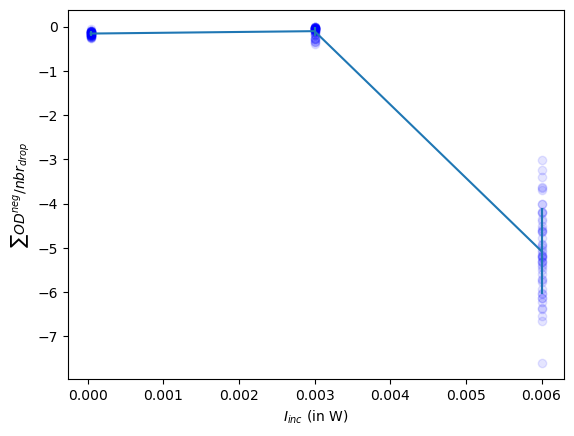

In [93]:
close("all")
fig = subplots()

errorbar(I_inc, vec(mean(sum_neg_OD_norm_drop, dims=2)), yerr=vec(std(sum_neg_OD_norm_drop, dims=2)))

for (i, ODs) in enumerate(ODs_datasets)
    for j in 1:length(ODs)
        scatter(I_inc[i], sum_neg_OD_norm_drop[i, j], color="b", alpha = 0.1)
    end
end

xlabel(L"$I_{inc}$ (in W)")
ylabel(L"\sum OD^{neg}/nbr_{drop}")

# pygui(true); show();
pygui(false);

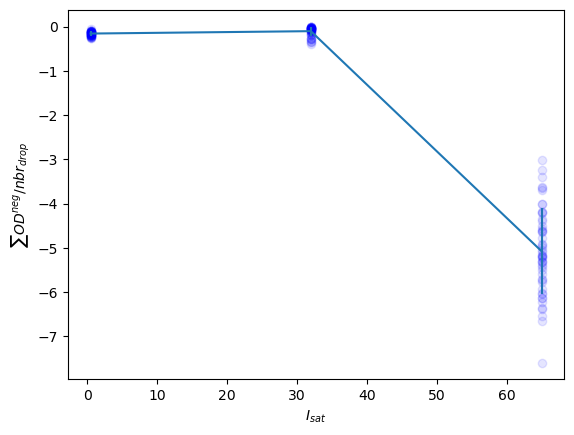

In [95]:
close("all")
fig = subplots()

errorbar(I_sat, vec(mean(sum_neg_OD_norm_drop, dims=2)), yerr=vec(std(sum_neg_OD_norm_drop, dims=2)))

for (i, ODs) in enumerate(ODs_datasets)
    for j in 1:length(ODs)
        scatter(I_sat[i], sum_neg_OD_norm_drop[i, j], color="b", alpha = 0.1)
    end
end

xlabel(L"I_{sat}")
ylabel(L"\sum OD^{neg}/nbr_{drop}")

# pygui(true); show();
pygui(false);

# Brouillons

In [ ]:
# droplet_size=2.5
# img = imshow(Kernel.gaussian(droplet_size))
# cb = colorbar(img)


# OD = ODs_datasets[1][3]

# droplet_radius = 5
# threshold_droplets = std(OD)*1.6


# OD = ODs_datasets[1][2]

# droplet_radius = 5
# threshold_droplets = (maximum(OD)-minimum(OD))*0.1

# 1 3 0.10102935788060385
# 1.6338747426476081
# 0.09927150877302528
# 1.4732203798537749

# 3 2 0.06563238524559785
# 1.4616142938481558
# 0.06873525678621482
# 1.3966498484261414


# close("all")
# fig, axs = subplots(1, 3, figsize=(10, 5))

# axs[1].imshow(OD)
# axs[2].imshow(label_blobs)
# axs[3].imshow(OD)
# axs[2].scatter([c[1] for c in centers], [c[2] for c in centers], s=10, marker="x", color="r")
# axs[3].scatter([c[1] for c in centers], [c[2] for c in centers], s=10, marker="x", color="r")

# # pygui(true); show()
# pygui(false)

# OD = ODs_datasets[1][5]

# droplet_radius = 2.5
# # threshold_droplets = std(OD)*45
# threshold_droplets = (maximum(OD)-minimum(OD))*2.5
# size_kernel_smooth = 5
# smooth_OD = smooth_imgs(OD, size_kernel_smooth)
# centers, label_blobs = find_droplets(smooth_OD, droplet_radius, threshold_droplets)

  
# close("all")
# fig, axs = subplots(1, 4, figsize=(10, 5))

# axs[1].imshow(OD)
# axs[2].imshow(smooth_OD)

# axs[3].imshow(label_blobs)
# axs[4].imshow(OD)
# axs[3].scatter([c[1] for c in centers], [c[2] for c in centers], s=10, marker="x", color="r")
# axs[4].scatter([c[1] for c in centers], [c[2] for c in centers], s=10, marker="x", color="r")

# # pygui(true); show()
# pygui(false)

# OD = ODs_datasets[3][3]

# droplet_radius = 6
# threshold_droplets = std(OD)*2
# centers, label_blobs = find_droplets(OD, droplet_radius, threshold_droplets)

# centers_double, double_blob = find_droplets(label_blobs, 6, threshold_droplets)

# close("all")
# fig, axs = subplots(1, 3, figsize=(15, 5))

# axs[1].imshow(OD)
# axs[2].imshow(label_blobs)

# # axs[2].scatter([c[1] for c in centers], [c[2] for c in centers], s=10, marker="x", color="r")

# axs[3].imshow(double_blob)
# axs[3].scatter([c[1] for c in centers], [c[2] for c in centers], s=10, marker="x", color="r")

# pygui(true); show()
# # pygui(false)

# img = load("imgs/ODs/1.png")
# gry = Gray.(img)

# # Parameters
# σ = 50   # blob scale (increase for larger blobs)

# # Laplacian of Gaussian
# log_kernel = Kernel.LoG(σ)
# response = imfilter(gry, log_kernel)



#     close("all")
# fig = subplots() 

# idx = findall(label_blobs .== 1)

# scatter(mean([i[2]-1 for i in idx]), mean([i[1]-1 for i in idx]), color="r")
# imshow(label_blobs)
# pygui(true); show()
# OD = ODs_datasets[3][1]

# close("all")
# fig, axs = subplots()
# img = axs.imshow(OD, cmap="plasma") #, aspect="auto"


# σ = 3.0
# log_kernel = Kernel.LoG(σ)
# response = imfilter(img, log_kernel)

# pygui(false)

# for (i, ODs) in ProgressBar(enumerate(ODs_datasets))
#     for (j, OD) in enumerate(ODs)
        


#         img = axs.imshow(OD, cmap="plasma") #, aspect="auto"
#         cb = colorbar(img)
#         savefig("imgs/ODs_mask/"*split(pathdir_date, "/")[2]*"/"*dir_names_datasets[i]*"/$(j-1).png")
#         cb.remove()
#         axs.clear()
#     end
# end